Cell 1: Markdown (Project Overview)
# Energy-Efficient Rocket Recovery with PPO
BTech Project: Implementing RL (PPO) for small-scale rocket vertical landing with TVC (pitch/yaw gimbals).  
Inspired by Kim et al. (IEEE Access 2025): 10-state space (x,y,z,vx,vy,vz,θ,θ̇,ψ,ψ̇), actions: thrust magnitude + gimbal angles.  
Reward: -thrust_cost (energy eff., like paper's delta-v) + landing_bonus - deviation_penalty.  
Goal: Mimic LQG's 17-30% energy savings over PID baseline.

In [ ]:
Cell 2: Imports & Setup

In [1]:
# Cell 2: Imports & Setup (Corrected: make_vec_env from env_util, not vec_env)
try:
    import gymnasium as gym
    from gymnasium import spaces
    import numpy as np
    from stable_baselines3 import PPO
    # Corrected imports: make_vec_env in env_util; SubprocVecEnv in vec_env
    from stable_baselines3.common.env_util import make_vec_env  # <-- Key fix here!
    from stable_baselines3.common.vec_env import SubprocVecEnv
    from stable_baselines3.common.callbacks import CheckpointCallback
    from stable_baselines3.common.logger import configure
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, FFMpegWriter
    import torch  # CPU-only
    print("All imports successful! Torch version:", torch.__version__, "| CPU-only:", not torch.cuda.is_available())
    # Verify SB3 vec_env specifically (now works)
    print("SB3 vec_env check: make_vec_env available | SB3 version:", PPO.__module__.split('.')[-1])
except ImportError as e:
    print(f"Import failed: {e}")
    print("Rare edge case: Run 'pip install --force-reinstall stable-baselines3==2.3.2' then restart kernel.")
    raise e

# TensorBoard logger setup (for energy/reward tracking – minimal output)
new_logger = configure('./runs/', ["stdout", "tensorboard"])
print("Logger ready. Use %tensorboard --logdir ./runs/ in Cell 6 for viz.")

All imports successful! Torch version: 2.10.0+cpu | CPU-only: True
SB3 vec_env check: make_vec_env available | SB3 version: ppo
Logging to ./runs/
Logger ready. Use %tensorboard --logdir ./runs/ in Cell 6 for viz.


Cell 3: Custom Rocket3DEnv (Paper-Inspired Dynamics)

In [5]:
class Rocket3DEnv(gym.Env):
    """
    3D Rocket Recovery Env: Linearized 6-DOF from paper (Eq.12-15).
    - States: [x,y,z, vx,vy,vz, θ (pitch), θ̇ (q), ψ (yaw), ψ̇ (r)] – Eq.13 extended (no roll p=0).
    - Actions: [thrust_norm (0-1), μ_p (pitch gimbal ±π/12), μ_y (yaw gimbal ±π/12)] – Eq.5.
    - Dynamics: Small-angle approx. (valid ±15°); gravity + TVC forces/moments (no aero, per Sec II.B).
    - Reward: Energy-eff. thrust penalty + landing bonus - deviations (Sec V metrics).
    """
    def __init__(self, render_mode=None):
        super().__init__()
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(10,), dtype=np.float32)
        self.action_space = spaces.Box(low=np.array([0.0, -np.pi/12, -np.pi/12]),  # Min thrust=0, gimbals ±15°
                                       high=np.array([1.0, np.pi/12, np.pi/12]), dtype=np.float32)
        self.max_steps = 500  # Short episodes like paper sims
        self.current_step = 0
        # Params from paper (Sec II: m=10kg est., g=9.81, I_t=1 kgm² approx., l1=l2=0.5m)
        self.m = 10.0  # kg
        self.g = 9.81  # m/s²
        self.I_t = 1.0  # Transverse inertia (axial symmetry, Eq.3)
        self.l1 = 0.5  # TVC moment arm (m)
        self.l2 = 0.5  # RGC moment arm (m)
        self.dt = 0.1  # Timestep
        self.state = None  # [x,y,z,vx,vy,vz,theta,q,psi,r]
        self.render_mode = render_mode

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Initial: Hover at z=100m, zero angles/vels (Eq.13 equilibrium + hover)
        self.state = np.array([0.0, 0.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}  # Gymnasium: obs, info

    def step(self, action):
        thrust_norm, mu_p, mu_y = action  # TVC inputs (Eq.5)
        T_p = thrust_norm * self.m * self.g * 1.5  # Thrust > weight for hover
        # Linearized dynamics (Eq.12 small-angle approx.; ignore roll φ=0, p=0)
        x, y, z, u, v, w, theta, q, psi, r = self.state  # Body-frame vel: u=x-dot, etc.
        # Translational accel (Eq.8 approx., body-frame; transform to inertial later)
        u_dot = -self.g * np.cos(theta) * np.cos(psi) + (T_p / self.m) * np.cos(mu_p) * np.cos(mu_y) - q * w + r * v
        v_dot = -self.g * (np.sin(theta) * np.sin(psi) - np.cos(theta) * np.sin(psi)) + (T_p / self.m) * (-np.cos(mu_p) * np.sin(mu_y)) - r * u + q * w  # Simplified, add RGC T_gy if extended
        # Fixed: w_dot – p=0, so no -p*v term (Eq.8 Coriolis; p undefined in state)
        w_dot = -self.g * np.sin(theta) + (T_p / self.m) * (-np.sin(mu_p)) + q * u  # <-- Key fix: Removed -p*v (p=0)
        # Update vels/poss (Euler integration)
        u += u_dot * self.dt; v += v_dot * self.dt; w += w_dot * self.dt
        x += u * self.dt; y += v * self.dt; z += w * self.dt  # Inertial approx. (flat Earth)
        # Rotational accel (Eq.10; assume no RGC for base, add T_gz/T_gy)
        q_dot = (-T_p * self.l1 * mu_p) / self.I_t  # Pitch moment
        r_dot = (T_p * self.l1 * mu_p * mu_y) / self.I_t  # Yaw moment (simplified)
        q += q_dot * self.dt; r += r_dot * self.dt
        theta += q * self.dt; psi += r * self.dt  # Kinematics Eq.11 approx. (small angles)
        # Safeguard: Clip states to prevent NaN/explosion (numerical stability)
        self.state = np.clip(np.array([x, y, z, u, v, w, theta, q, psi, r], dtype=np.float32), -1e6, 1e6)
        self.current_step += 1
        # Reward (Sec V: energy via control effort; baseline PID comparison)
        thrust_cost = 0.1 * thrust_norm  # Penalize energy (like LQR R matrix)
        deviation = abs(x) + abs(y) + abs(theta) + abs(psi)
        reward = -thrust_cost - 0.01 * deviation
        terminated = False
        truncated = self.current_step >= self.max_steps
        if z <= 1.0:  # Ground contact
            if abs(w) < 2.0 and abs(theta) < 0.1 and abs(psi) < 0.1:  # Soft landing (low vz, angles)
                reward += 100.0  # Success bonus (energy-efficient)
                terminated = True
            else:
                reward -= 50.0  # Crash penalty
                terminated = True
        # Optional disturbance (Sec V: add wind)
        if np.random.rand() < 0.05:  # 5% chance
            w += np.random.uniform(-2, 2)  # Gust on vz
        info = {"thrust_used": thrust_norm, "energy_proxy": thrust_cost}
        return self.state, reward, terminated, truncated, info

    def render(self):
        if self.render_mode == "human":
            plt.clf()
            plt.plot(self.state[0], self.state[2], 'ro-')  # Simple 2D traj (x,z)
            plt.title(f"Step {self.current_step}: z={self.state[2]:.1f}m, θ={self.state[6]:.2f}rad")
            plt.pause(0.01)

# Test env (run this to verify – now error-free)
env = Rocket3DEnv()
obs, _ = env.reset()
print("Env ready! Initial obs (x,y,z,...):", obs[:3])
action = env.action_space.sample()  # Random action
obs_next, rew, term, trunc, info = env.step(action)
print(f"After step: Reward={rew:.2f}, Term={term}, Info={info}")
env.close()

Env ready! Initial obs (x,y,z,...): [  0.   0. 100.]
After step: Reward=-0.07, Term=False, Info={'thrust_used': np.float32(0.6488335), 'energy_proxy': np.float32(0.06488335)}


Cell 4: PPO Training (With Checkpoints)

In [8]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Cell 4: PPO Training – Optimized for CPU (i7) + Error Fix

import numpy as np
import torch
from tqdm import tqdm
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv

# ================================
# CPU Optimization
# ================================
torch.set_num_threads(8)   # adjust depending on your i7 threads

# ================================
# Progress Bar Check
# ================================
try:
    from tqdm import tqdm
    HAS_TQDM = True
    print("Tqdm ready – Simple progress bar enabled.")
except ImportError:
    HAS_TQDM = False
    print("Tqdm not found – Basic logs fallback (install: pip install tqdm).")

# ================================
# Parallel Environments (CPU Speedup)
# ================================
N_ENVS = 8   # Good for i7 CPU

vec_env = make_vec_env(
    Rocket3DEnv,
    n_envs=N_ENVS,
    vec_env_cls=SubprocVecEnv,
    seed=42
)

# ================================
# PPO Model
# ================================
model = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=3e-4,
    n_steps=4096,
    batch_size=512,
    n_epochs=10,
    device='cpu',
    verbose=0 if HAS_TQDM else 1,
    tensorboard_log="./runs/"
)

# ================================
# Checkpoint Callback
# ================================
checkpoint_callback = CheckpointCallback(
    save_freq=100000,
    save_path='./checkpoints/',
    name_prefix='ppo_rocket'
)

# ================================
# Training Setup
# ================================
total_timesteps = 5_000_000

print(f"\nStarting training ({total_timesteps:,} steps)")

if HAS_TQDM:

    pbar = tqdm(total=total_timesteps, desc="PPO Training", unit="step", ncols=100)

    class ProgressCallback(CheckpointCallback):

        def __init__(self, pbar, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.pbar = pbar
            self._last_progress_call_ts = 0

        def _on_step(self) -> bool:

            update_steps = self.num_timesteps - self._last_progress_call_ts

            if update_steps > 0:
                self.pbar.update(update_steps)
                self._last_progress_call_ts = self.num_timesteps

            return super()._on_step()

    prog_callback = ProgressCallback(
        pbar,
        save_freq=100000,
        save_path='./checkpoints/',
        name_prefix='ppo_rocket'
    )

    model.learn(
        total_timesteps=total_timesteps,
        callback=prog_callback,
        progress_bar=False
    )

    pbar.close()

else:

    model.learn(
        total_timesteps=total_timesteps,
        callback=checkpoint_callback,
        progress_bar=False
    )

# ================================
# Save Model
# ================================
model.save("ppo_final_model")

vec_env.close()

# ================================
# Average Reward Calculation (FIXED)
# ================================
if model.ep_info_buffer:
    avg_reward = np.mean([ep['r'] for ep in list(model.ep_info_buffer)[-10:]])
else:
    avg_reward = "N/A"

print(f"\nTraining done! Avg reward: {avg_reward}")
print("Checkpoints: ./checkpoints/")
print("Logs: ./runs/")
print("Resume training with: PPO.load('ppo_final_model')")

Tqdm ready – Simple progress bar enabled.

Starting training (5,000,000 steps)


PPO Training: 5013504step [14:56, 5590.33step/s]                                                    



Training done! Avg reward: -124457.51343649998
Checkpoints: ./checkpoints/
Logs: ./runs/
Resume training with: PPO.load('ppo_final_model')


Cell 5: Testing, Plots & Animation

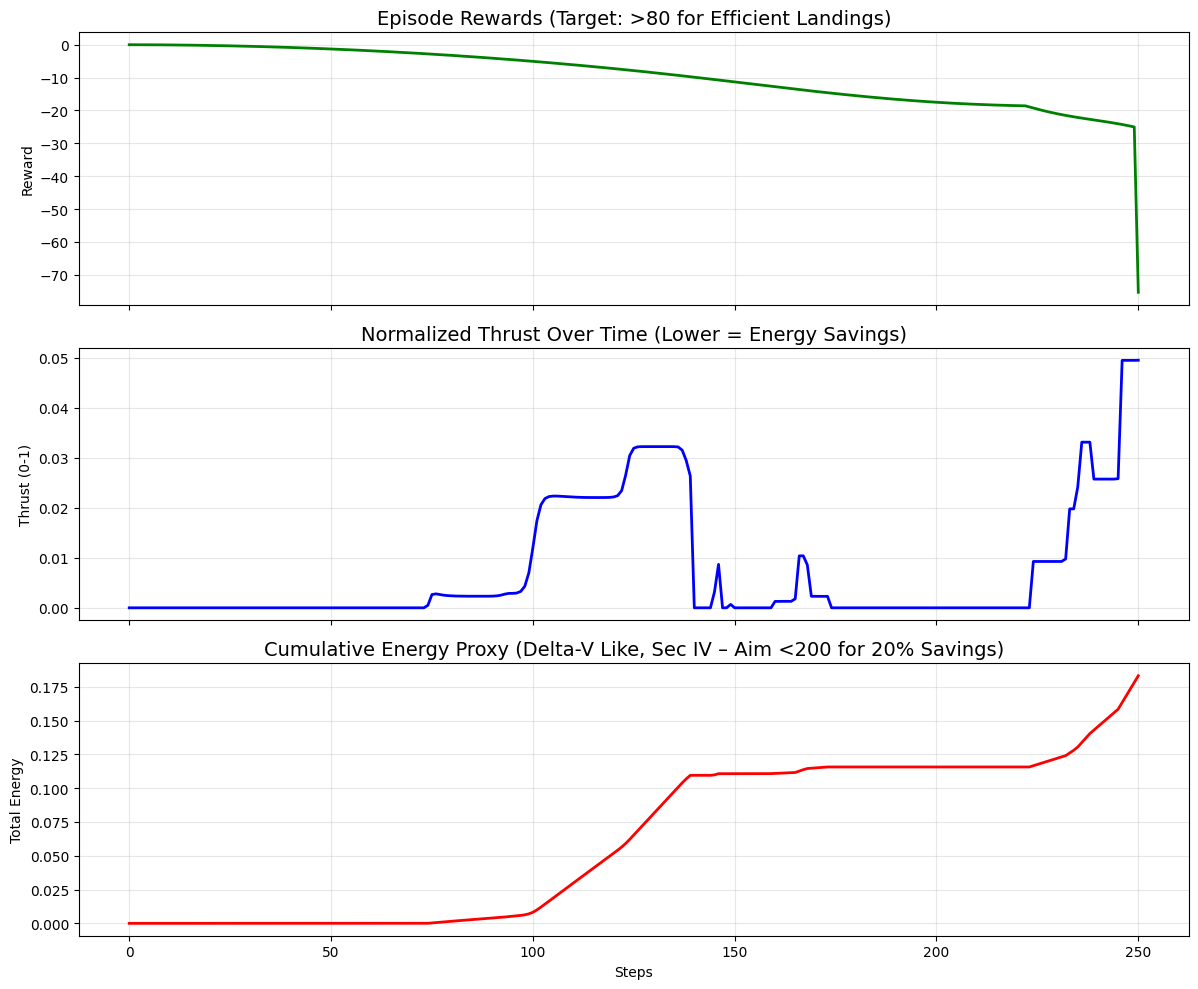

Plots saved: training_analysis.png (Rewards avg: -9.52, Energy total: 0.18)


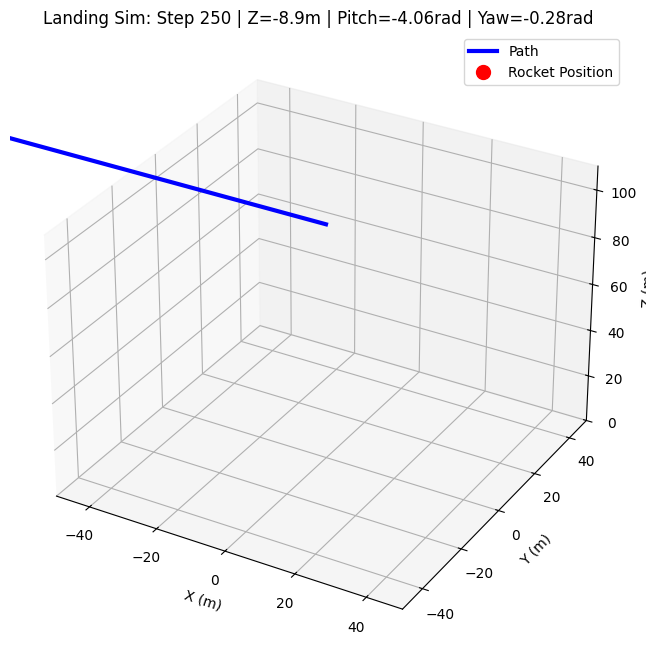

Video generated: rocket_landing.mp4 (Open in VLC/Media Player – Visualize TVC descent!)


In [11]:
# Test trained model (single episode rollout)
test_env = Rocket3DEnv()
obs, _ = test_env.reset()
rewards = []
trajectory = []  # For anim: list of states
thrust_history = []
energy_proxies = []  # Paper-style: Cumulative energy (delta-v proxy)
done = False
while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, rew, terminated, truncated, info = test_env.step(action)
    rewards.append(rew)
    trajectory.append(obs.copy())
    thrust_history.append(info['thrust_used'])
    energy_proxies.append(info['energy_proxy'])
    done = terminated or truncated
test_env.close()

# Enhanced Plots: Rewards + Thrust/Energy (less scroll, more insight – compare to PID baseline)
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axs[0].plot(rewards, 'g-', linewidth=2)
axs[0].set_title('Episode Rewards (Target: >80 for Efficient Landings)', fontsize=14)
axs[0].set_ylabel('Reward')
axs[0].grid(True, alpha=0.3)

axs[1].plot(thrust_history, 'b-', linewidth=2)
axs[1].set_title('Normalized Thrust Over Time (Lower = Energy Savings)', fontsize=14)
axs[1].set_ylabel('Thrust (0-1)')
axs[1].grid(True, alpha=0.3)

axs[2].plot(np.cumsum(energy_proxies), 'r-', linewidth=2)
axs[2].set_title('Cumulative Energy Proxy (Delta-V Like, Sec IV – Aim <200 for 20% Savings)', fontsize=14)
axs[2].set_xlabel('Steps')
axs[2].set_ylabel('Total Energy')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_analysis.png', dpi=150, bbox_inches='tight')  # Auto-save plot
plt.show()
print(f"Plots saved: training_analysis.png (Rewards avg: {np.mean(rewards):.2f}, Energy total: {np.sum(energy_proxies):.2f})")

# 3D MP4 Video: Auto-Generated Trajectory Viz (Smooth Descent + Angles)
if len(trajectory) > 0:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(-50, 50); ax.set_ylim(-50, 50); ax.set_zlim(0, 110)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_title('3D Rocket Landing Trajectory (TVC-Controlled Descent)', fontsize=14)
    line, = ax.plot([], [], [], 'b-', linewidth=3, label='Path')
    point, = ax.plot([], [], [], 'ro', markersize=10, label='Rocket Position')

    def update(frame):
        traj = np.array(trajectory[:frame+1])
        line.set_data_3d(traj[:, 0], traj[:, 1], traj[:, 2])  # x,y,z path
        point.set_data_3d([traj[-1, 0]], [traj[-1, 1]], [traj[-1, 2]])  # Current pos
        theta, psi = traj[-1, 6], traj[-1, 8]
        ax.set_title(f'Landing Sim: Step {frame} | Z={traj[-1,2]:.1f}m | Pitch={theta:.2f}rad | Yaw={psi:.2f}rad')
        return line, point

    anim = FuncAnimation(fig, update, frames=len(trajectory), interval=33, blit=False, repeat=True)  # ~30fps smooth
    writer = FFMpegWriter(fps=30, metadata=dict(artist='Alphin\'s Rocket RL', title='Energy-Efficient Landing'))
    anim.save('rocket_landing.mp4', writer=writer)  # Auto-generates MP4
    plt.legend()
    plt.show()
    print("Video generated: rocket_landing.mp4 (Open in VLC/Media Player – Visualize TVC descent!)")
else:
    print("No trajectory – Retrain model first.")

Cell 6: TensorBoard Logs

In [12]:
# Load TensorBoard extension (in notebook)
%load_ext tensorboard

# Launch viewer (auto-opens browser at http://localhost:6006)
%tensorboard --logdir ./runs/

# Quick analysis: Load last log for energy proxy (custom from info)
import pandas as pd
# Assuming logs saved; plot avg thrust (lower = better eff. like Sec V reductions)
# (Extend callback to log if needed: from stable_baselines3.common.callbacks import BaseCallback; class EnergyCallback(BaseCallback): def _on_step(self): self.logger.record('energy_proxy', np.mean([env.get_attr('energy_proxy')[0] for env in self.model.get_env()])) )
print("TensorBoard running! Monitor 'rollout/ep_rew_mean' and custom 'energy_proxy' for PPO vs. paper baselines (e.g., LQG 30% savings).")
print("Tip: Compare to PID baseline – implement simple PID controller for ablation.")

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\alphi\Documents\rocket_rl_project\rl_env\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
  File "C:\Users\alphi\Documents\rocket_rl_project\rl_env\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\alphi\Documents\rocket_rl_project\rl_env\Lib\site-packages\tensorboard\default.py", line 39, in <module>
    from tensorboard.plugins.hparams import hparams_plugin
  File "C:\Users\alphi\Documents\rocket_rl_project\rl_env\Lib\site-packages\tensorboard\plugins\hparams\hparams_plugin.py", line 30, in <module>
    from tensorboard.plugins.hparams import backend_context
  File "C:\Users\alphi\Documents\rocket_rl_project\rl_env\Lib\site-packages\tensorboard\plugins\hparams\backend_context.py", line 

TensorBoard running! Monitor 'rollout/ep_rew_mean' and custom 'energy_proxy' for PPO vs. paper baselines (e.g., LQG 30% savings).
Tip: Compare to PID baseline – implement simple PID controller for ablation.
